## Многофакторная линейная регрессия

Источник данных: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset

Набор данных о здоровье сна и образе жизни включает такие данные, как пол, возраст, профессия, продолжительность сна, качество сна, уровень физической активности, уровень стресса, категория ИМТ, артериальное давление, частота сердечных сокращений, количество шагов в день, а также наличие или отсутствие нарушений сна.

<details>
<summary>Описание признаков</summary>

| Признак | Описание |
|---------|----------|
| Person ID | An identifier for each individual |
| Gender | The gender of the person (Male/Female) |
| Age | The age of the person in years |
| Occupation | The occupation or profession of the person |
| Sleep Duration (hours) | The number of hours the person sleeps per day |
| Quality of Sleep (scale: 1-10) | A subjective rating of the quality of sleep, ranging from 1 to 10 |
| Physical Activity Level (minutes/day) | The number of minutes the person engages in physical activity daily |
| Stress Level (scale: 1-10) | A subjective rating of the stress level experienced by the person, ranging from 1 to 10 |
| BMI Category | The BMI category of the person (e.g., Underweight, Normal, Overweight) |
| Blood Pressure | The blood pressure measurement of the person, indicated as systolic pressure over diastolic pressure |
| Heart Rate (bpm) | The resting heart rate of the person in beats per minute |
| Daily Steps | The number of steps the person takes per day |
| Sleep Disorder | The presence or absence of a sleep disorder in the person (None, Insomnia, Sleep Apnea) |

</details>

#### Цель: изучить зависимость продолжительности сна от субъективных и объективных показателей состояния здоровья человека.

#### Задача: построить многофакторную регрессионную модель, отражающую зависимость продолжительности сна от нескольких других показателей (пол, возраст, давление, чсс и т.д.).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

Исходные данные

In [2]:
data = pd.read_csv("data/sleep.csv")
data.sample(5)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
46,47,Male,31,Doctor,7.7,7,75,6,Normal,120/80,70,8000,NaN
164,165,Male,40,Lawyer,7.9,8,90,5,Normal,130/85,68,8000,NaN
327,328,Female,53,Engineer,8.5,9,30,3,Normal,125/80,65,5000,NaN
91,92,Male,35,Engineer,7.3,8,60,4,Normal,125/80,65,5000,NaN
24,25,Male,30,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


Некоторые статистики по признакам:

In [3]:
data.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [4]:
data.describe(include=["O"])

C:\Users\temic\AppData\Local\Temp\ipykernel_14016\1126752233.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=["O"])


,Gender,Occupation,BMI Category,Blood Pressure,Sleep Disorder
count,374,374,374,374,155
unique,2,11,4,25,2
top,Male,Nurse,Normal,130/85,Sleep Apnea
freq,189,73,195,99,78


Пропущенные значения:

In [5]:
data.isna().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Заменим пропущенные значения признака "Нарушение сна" числом 0, все остальные 1

Заменим значения пола на 0 (мужской пол) и 1 (женский)

Объединим значения BMI, отличные от нормального в одну категорию (1).

In [6]:
data["Sleep Disorder"] = (data["Sleep Disorder"].isna()).astype(int)
data["Gender"] = (data["Gender"] == "Female").astype(int)
data["BMI Category"] = (data["BMI Category"] != "Normal").astype(int)

ID человека в датасете, очевидно, совсем не влияет на длительность сна, поэтому этот признак не будет использован.

In [7]:
data = data.drop(columns=["Person ID"])

### Приведение всех данных к стандартному виду

Категориальные признаки закодируем, признак "Blood Pressure" разделим на два признака -- верхнее и нижнее давление

In [8]:
def split_blood_pressure(df):
    df_copy = df.copy()

    split = df_copy["Blood Pressure"].str.split('/', expand=True)
    df_copy["Systolic"] = pd.to_numeric(split[0], errors="coerce")
    df_copy["Diastolic"] = pd.to_numeric(split[1], errors="coerce")
    df_copy = df_copy.drop('Blood Pressure', axis=1)
    
    return df_copy

In [9]:
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

numeric_features = data.select_dtypes(include="number").columns.tolist()
numeric_features.remove("Sleep Duration")
numeric_features.extend(["Systolic", "Diastolic"])
cat_features = data.select_dtypes(include="object").columns.drop("Blood Pressure").tolist()

pressure_tf = FunctionTransformer(split_blood_pressure)

pipeline = make_pipeline(
    pressure_tf,
    make_column_transformer(
        (MinMaxScaler(), numeric_features),
        (OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_features),
        verbose_feature_names_out=False,
        remainder="passthrough"
    )
)
data_transformed = pipeline.fit_transform(data)

C:\Users\temic\AppData\Local\Temp\ipykernel_14016\1092167817.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = data.select_dtypes(include="object").columns.drop("Blood Pressure").tolist()


Измененные данные (все значения от 0 до 1)

In [10]:
ct = pipeline.named_steps['columntransformer']
column_names = ct.get_feature_names_out()
df_transformed = pd.DataFrame(data_transformed, columns=column_names)
df_transformed.head(3)

,Gender,Age,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,...,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,Sleep Duration
0,0.0,0.00000,0.4,0.2,0.6,1.0,0.571429,0.171429,1.0,0.407407,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.1
1,0.0,0.03125,0.4,0.5,1.0,0.0,0.476190,1.000000,1.0,0.370370,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.2
2,0.0,0.03125,0.4,0.5,1.0,0.0,0.476190,1.000000,1.0,0.370370,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.2


Разделение выборки на тренировочную и тестовую (20% значений идут в тест)

In [11]:
from sklearn.model_selection import train_test_split

y = df_transformed["Sleep Duration"]
X = df_transformed.drop(columns=["Sleep Duration"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Модель регрессии по МНК

In [12]:
import statsmodels.api as sm

X_train_with_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_with_const)
model_fitted = model.fit()
model_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Sleep Duration   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     149.1
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          7.79e-136
Time:                        11:06:50   Log-Likelihood:                 11.300
No. Observations:                 299   AIC:                             19.40
Df Residuals:                     278   BIC:                             97.11
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                               5.5040      0.244     22.541      0.000       5.023       5.985
Gender                              0.2784      0.097      2.883      0.004       0.088       0.468
Age                                 0.2118      0.204      1.037      0.300      -0.190       0.614
Quality of Sleep                    2.3532      0.301      7.826      0.000       1.761       2.945
Physical Activity Level             0.6161      0.098      6.261      0.000       0.422       0.810
Stress Level                       -0.2364      0.174     -1.357      0.176      -0.579       0.107
BMI Category                        0.0119      0.067      0.177      0.860      -0.121       0.144
Heart Rate                          0.2565      0.155      1.659      0.098      -0.048       0.561
Daily Steps                        -0.9405      0.157     -5.973      0.000      -1.250      -0.631
Sleep Disorder                     -0.0495      0.059     -0.839      0.402      -0.166       0.067
Systolic                           -3.0396      0.433     -7.024      0.000      -3.891      -2.188
Diastolic                           2.4162      0.421      5.744      0.000       1.588       3.244
Occupation_Accountant              -0.1977      0.085     -2.327      0.021      -0.365      -0.030
Occupation_Doctor                   0.7676      0.066     11.643      0.000       0.638       0.897
Occupation_Engineer                 0.8281      0.070     11.822      0.000       0.690       0.966
Occupation_Lawyer                   0.7648      0.081      9.400      0.000       0.605       0.925
Occupation_Manager               1.253e-15   1.67e-16      7.497      0.000    9.24e-16    1.58e-15
Occupation_Nurse                    0.1369      0.098      1.394      0.164      -0.056       0.330
Occupation_Sales Representative     1.3719      0.177      7.748      0.000       1.023       1.720
Occupation_Salesperson              0.6740      0.079      8.576      0.000       0.519       0.829
Occupation_Scientist                0.7477      0.175      4.271      0.000       0.403       1.092
Occupation_Software Engineer        0.3018      0.149      2.030      0.043       0.009       0.595
Occupation_Teacher                  0.1087      0.076      1.423      0.156      -0.042       0.259
==============================================================================
Omnibus:                       31.549   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               79.535
Skew:                           0.485   Prob(JB):                     5.36e-18
Kurtosis:                       5.333   Cond. No.                     4.18e+17
==============================================================================

Notes:
[

Обычный и скорректированный коэффициенты детерминации равны 0.907 и 0.9

#### Проверка значимости коэффициентов:

p-value < 0.05 у таких признаков возраст, категория BMI, расстройство сна, пол, все субъективные и объективные показатели состояния здоровья (уровень стресса, давление и т.д.). Данные признаки значимы в контексте построенной модели.

p-value возраста, наличия расстройств сна, BMI, некоторых профессий (медсестра, учитель, менеджер, ученый) > 0.05, значит данные признаки не значимы.

Построим модель без учета незначимых признаков:

In [13]:
occupations = [col for col in df_transformed.columns if "Occupation" in col]
X = df_transformed.drop(columns=occupations + ["Age", "BMI Category", "Sleep Disorder", "Sleep Duration"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train_with_const = sm.add_constant(X_train)

model2 = sm.OLS(y_train, X_train_with_const)
model2_fitted = model2.fit()
print("                     2 ШАГ")
model2_fitted.summary()

                     2 ШАГ


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Sleep Duration   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     179.2
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          1.76e-107
Time:                        11:06:50   Log-Likelihood:                -91.071
No. Observations:                 299   AIC:                             200.1
Df Residuals:                     290   BIC:                             233.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       5.7422      0.202     28.479      0.000       5.345       6.139
Gender                     -0.2733      0.049     -5.537      0.000      -0.370      -0.176
Quality of Sleep            2.8366      0.224     12.691      0.000       2.397       3.276
Physical Activity Level     0.4083      0.132      3.086      0.002       0.148       0.669
Stress Level               -0.2312      0.173     -1.334      0.183      -0.572       0.110
Heart Rate                  0.2005      0.180      1.116      0.265      -0.153       0.554
Daily Steps                -0.6343      0.206     -3.078      0.002      -1.040      -0.229
Systolic                   -1.0203      0.404     -2.524      0.012      -1.816      -0.225
Diastolic                   0.7648      0.398      1.920      0.056      -0.019       1.549
==============================================================================
Omnibus:                       20.588   Durbin-Watson:                   1.889
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.111
Skew:                           0.528   Prob(JB):                     0.000117
Kurtosis:                       2.419   Cond. No.                         53.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

У модели, полученной на втором шаге опять появился незначимый признак -- частота пульса во сне.

Коэффициент детерминации стал хуже по сравнению с первой моделью ($R^2 = 0.84, R_{скорр}^2 = 0.836$)

Построим еще одну модель, но без учета частоты пульса:

In [14]:
occupations = [col for col in df_transformed.columns if "Occupation" in col]
X = df_transformed.drop(columns=occupations + ["Age", "BMI Category", "Sleep Disorder", "Sleep Duration", "Heart Rate"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train_with_const = sm.add_constant(X_train)

model3 = sm.OLS(y_train, X_train_with_const)
model3_fitted = model3.fit()
print("                     3 ШАГ")
model3_fitted.summary()

                     3 ШАГ


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Sleep Duration   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     201.4
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          1.34e-107
Time:                        11:06:50   Log-Likelihood:                -92.148
No. Observations:                 299   AIC:                             200.3
Df Residuals:                     291   BIC:                             229.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       6.1129      0.195     31.343      0.000       5.729       6.497
Gender                     -0.2161      0.049     -4.410      0.000      -0.313      -0.120
Quality of Sleep            2.4810      0.219     11.324      0.000       2.050       2.912
Physical Activity Level     0.5674      0.106      5.348      0.000       0.359       0.776
Stress Level               -0.2664      0.158     -1.688      0.092      -0.577       0.044
Daily Steps                -0.8918      0.166     -5.367      0.000      -1.219      -0.565
Systolic                   -0.9160      0.405     -2.264      0.024      -1.712      -0.120
Diastolic                   0.6180      0.399      1.548      0.123      -0.168       1.404
==============================================================================
Omnibus:                       25.946   Durbin-Watson:                   1.932
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               13.510
Skew:                           0.345   Prob(JB):                      0.00117
Kurtosis:                       2.220   Cond. No.                         52.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Незначимыми оказались низкое давление и уровень стресса.

Коэффициент детерминации стал еще немного хуже ($R^2 = 0.831, R_{скорр}^2 = 0.827$)

Построим еще одну модель, чтобы увидеть изменения:

In [15]:
occupations = [col for col in df_transformed.columns if "Occupation" in col]
X = df_transformed.drop(columns=occupations + ["Age", "BMI Category", "Sleep Disorder", "Sleep Duration", "Stress Level", "Diastolic", "Heart Rate"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train_with_const = sm.add_constant(X_train)

model4 = sm.OLS(y_train, X_train_with_const)
model4_fitted = model4.fit()
print("                     4 ШАГ")
model4_fitted.summary()

                     4 ШАГ


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Sleep Duration   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     266.2
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          1.11e-106
Time:                        11:06:50   Log-Likelihood:                -102.47
No. Observations:                 299   AIC:                             216.9
Df Residuals:                     293   BIC:                             239.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       5.6101      0.096     58.250      0.000       5.421       5.800
Gender                     -0.1533      0.044     -3.483      0.001      -0.240      -0.067
Quality of Sleep            2.8600      0.095     30.030      0.000       2.673       3.047
Physical Activity Level     0.5801      0.104      5.591      0.000       0.376       0.784
Daily Steps                -0.8075      0.148     -5.474      0.000      -1.098      -0.517
Systolic                   -0.2797      0.078     -3.570      0.000      -0.434      -0.125
==============================================================================
Omnibus:                       21.275   Durbin-Watson:                   2.049
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.967
Skew:                           0.518   Prob(JB):                     0.000125
Kurtosis:                       2.392   Cond. No.                         15.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

На четвертом шаге осталось 5 признаков из исходных данных. Дальше будем рассматривать именно эту модель.

Общий вид:

$$ Продолжительность\_сна = -0.1533 \cdot Пол + 2.8716 \cdot Качество\_сна + 0.5566 \cdot Уровень\_активности \\
-0.7982 \cdot Количество\_шагов - 0.2669 \cdot Верхнее\_давление + 5.5951 $$

Свободный коэффициент 5.59 можно интерпретировать как базовую продолжительность сна (5ч 35мин), которая меняется в зависимости от приведенных факторов.

Наиболее сильное влияние на продолжительность сна оказывает субъективная оценка его качества от 1 до 10

Согласно полученным коэффициентам, при прочих равных женский пол связан с меньшей (на 9 минут) продолжительностью сна. При этом фактор пола наименее сильно влияет на продолжительность сна.

На первый взгляд связанные показатели оценки физической активности и количества пройденных шагов имеют коэффициенты с разными знаками.

In [16]:
len(model_fitted.resid)

299

1. Линейная связь
H0:Линейная связь отсутствует
H1:Наличие линейной связи
H0 отвергается -- линейная связь есть

2. Случайность остатков
H0:Остатки зависимы
H1:Остатки случайны


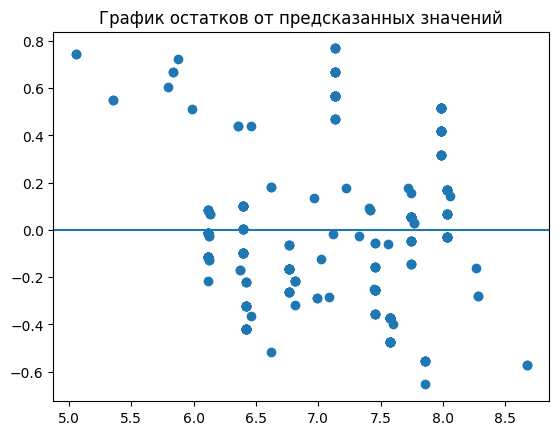


3. Мат ожидание
H0:M(ei) = 0
H1:M(ei) != 0
t расч. = 2.1209521713994813e-12
t табл. = 1.9680934526838219
H0 принимается -- мат. ожидание остатков равно нулю.

4. Дисперсия
H0:D(ei) = const (гомоскедастичность)
H1: наличие гетероскедастичности
Тест Бройша-Погана
p-value=1.930449657303926e-20
{'Lagrange multiplier statistic': np.float64(102.07469225871073), 'p-value': np.float64(1.930449657303926e-20), 'f-value': np.float64(30.374851434629974), 'f p-value': np.float64(7.385182861333185e-25)}
H0 отвергается -- дисперсия гетероскедастична

5. Автокоррелияция остатков
H0:Автокорреляция отсутствует
H1:Наличие автокорреляции
Тест Дарбина-Уотсона: 2.048885549485813
H0 подтверждается -- остатки независимы

6. Нормальность остатков
H0:Распределение остатков согласуется с нормальным
H1:распределеие остатков не согласуется с нормальным


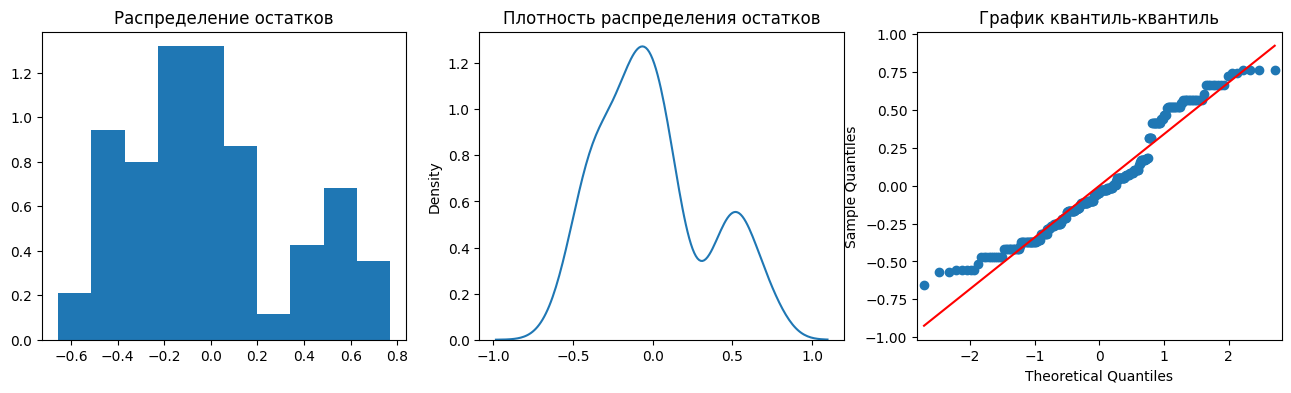

Тест Шапиро-Уилка: 0.9473420174668635, p-value=7.264558328391467e-09
Тест Колмогорова-Смирнова: 0.2878742603641308, p-value=1.9721858401642757e-22
p-value: 7.264558328391467e-09
H0 отвергается -- остатки не распределены нормально

7. Мультиколлинеарность
                   Признак       VIF
2  Physical Activity Level  3.224969
3              Daily Steps  2.801463
1         Quality of Sleep  1.340091
4                 Systolic  1.298804
0                   Gender  1.232693
Мультиколлинеарности признаков нет


In [82]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.stats.diagnostic import acorr_breusch_godfrey

def test_model(model_fitted):
    # residuals = model_fitted.resid
    if hasattr(model_fitted, 'resid'):
        residuals = model_fitted.resid
    else:
        if hasattr(model_fitted, 'fittedvalues'):
            residuals = model_fitted.model.endog - model_fitted.fittedvalues
    n = len(residuals)
    if hasattr(model_fitted, 'df_resid'):
        df_resid = model_fitted.df_resid
    else:
        n_params = np.sum(model_fitted.params != 0) if hasattr(model_fitted, 'params') else len(model_fitted.params)
        df_resid = n - n_params

    print("1. Линейная связь\nH0:Линейная связь отсутствует\nH1:Наличие линейной связи")
    if any(model4_fitted.pvalues >= 0.05):
        print("H0 принимается -- есть незначимые коэффициенты")
    else:
        print("H0 отвергается -- линейная связь есть")
    print()

    print("2. Случайность остатков\nH0:Остатки зависимы\nH1:Остатки случайны")
    plt.scatter(model_fitted.fittedvalues, residuals)
    plt.title("График остатков от предсказанных значений")
    plt.axhline(0)
    plt.show()
    print()

    print("3. Мат ожидание\nH0:M(ei) = 0\nH1:M(ei) != 0")
    mean = np.mean(residuals)
    std = np.std(residuals)
    n = len(residuals)
    tm = mean / std * n
    t = stats.t.ppf(1 - 0.05 / 2, df_resid)

    print(f"t расч. = {tm}")
    print(f"t табл. = {t}")
    if abs(tm) < t:
        print("H0 принимается -- мат. ожидание остатков равно нулю.")
    else:
        print("H0 отвергается -- мат. ожидание остатков не равно нулю.")
    print()


    print("4. Дисперсия\nH0:D(ei) = const (гомоскедастичность)\nH1: наличие гетероскедастичности")
    bp_test = het_breuschpagan(residuals, model_fitted.model.exog)
    labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
    results = dict(zip(labels, bp_test))
    print("Тест Бройша-Погана")
    print(f"p-value={results["p-value"]}")
    print(results)
    if results["p-value"] < 0.05:
        print("H0 отвергается -- дисперсия гетероскедастична")
    else:
        print("H0 принимается -- дисперсия гомоскедастична")
    print()

    print("5. Автокоррелияция остатков\nH0:Автокорреляция отсутствует\nH1:Наличие автокорреляции")
    dw = durbin_watson(residuals)
    print(f"Тест Дарбина-Уотсона: {dw}")
    if abs(dw - 2) < 0.5:
        print("H0 подтверждается -- остатки независимы")
    else:
        print("H0 отклоняется -- автокорреляция остатков присутствует")
    print()
    
    print("6. Нормальность остатков\nH0:Распределение остатков согласуется с нормальным\nH1:распределеие остатков не согласуется с нормальным")
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].hist(residuals, density=True)
    ax[0].set_title("Распределение остатков")
    sns.kdeplot(residuals, ax=ax[1])
    ax[1].set_title("Плотность распределения остатков")
    sm.qqplot(residuals, line='s', ax=ax[2])
    ax[2].set_title("График квантиль-квантиль")
    plt.show()
    shapiro, p_value = stats.shapiro(residuals)
    print(f"Тест Шапиро-Уилка: {shapiro}, p-value={p_value}")
    
    ks, p_value_ks = stats.kstest(residuals, 'norm', args=(0, 1))
    print(f"Тест Колмогорова-Смирнова: {ks}, p-value={p_value_ks}")
    print(f"p-value: {p_value}")

    if max(p_value, p_value_ks) < 0.05:
        print("H0 отвергается -- остатки не распределены нормально")
    else:
        print("H0 принимается -- остатки распределены нормально")
    print()

    print("7. Мультиколлинеарность")
    X['const'] = 1
    vif_data = pd.DataFrame()
    vif_data["Признак"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    print(vif_data[vif_data["Признак"] != 'const'].sort_values("VIF", ascending=False))

    if any(vif_data[vif_data["Признак"] != 'const']["VIF"] > 10):
        print(f"Мультиколлинеарные признаки:\n{vif_data[(vif_data["VIF"] > 10) & (vif_data["Признак"] != "const")]}")
    else:
        print(f"Мультиколлинеарности признаков нет")

test_model(model4_fitted)

Ошибка аппроксимации составила 

#### Проверка на тестовой выборке

Text(0.5, 1.0, 'Результаты прогноза по тестовой выборке')

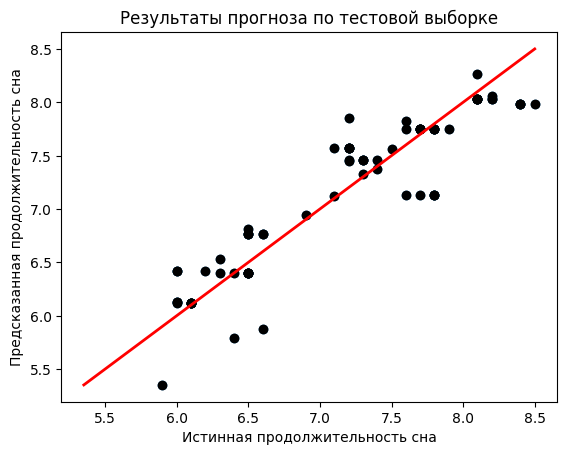

In [47]:
X_test_with_const = sm.add_constant(X_test)
y_pred = model4_fitted.predict(X_test_with_const)
plt.scatter(y_test, y_pred)

mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
plt.scatter(y_test, y_pred, c="black")
plt.plot([mn, mx], [mn, mx], c="red", lw="2.")
plt.xlabel("Истинная продолжительность сна")
plt.ylabel("Предсказанная продолжительность сна")
plt.title("Результаты прогноза по тестовой выборке")

### Ridge-регрессия

In [ ]:
model_ridge = sm.OLS(y_train, X_train_with_const)
model_ridge = model_ridge.fit_regularized(L1_wt=0)
print("                     Ridge-регрессия")
pd.DataFrame({"Признак": ["const"] + list(X_train.columns), "Коэффициент": model_ridge.params})

                     Ridge-регрессия


,Признак,Коэффициент
0,const,5.610062
1,Gender,-0.153284
2,Quality of Sleep,2.860002
3,Physical Activity Level,0.580053
4,Daily Steps,-0.807514
5,Systolic,-0.279657


Уравнение идентично полученному ранее уравнению без L2-регуляризации

$$ Продолжительность\_сна = -0.1532 \cdot Пол + 2.86 \cdot Качество\_сна + 0.58 \cdot Уровень\_активности \\
-0.8 \cdot Количество\_шагов - 0.279 \cdot Верхнее\_давление + 5.61 $$


1. Линейная связь
H0:Линейная связь отсутствует
H1:Наличие линейной связи
H0 отвергается -- линейная связь есть

2. Случайность остатков
H0:Остатки зависимы
H1:Остатки случайны


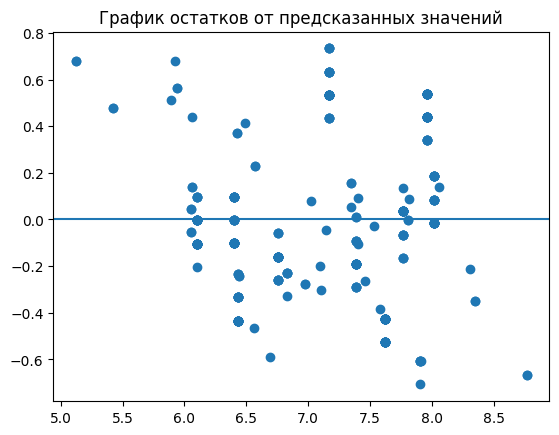


3. Мат ожидание
H0:M(ei) = 0
H1:M(ei) != 0
t расч. = -6.482991415055353
t табл. = 1.9680934526838219
H0 отвергается -- мат. ожидание остатков не равно нулю.

4. Дисперсия
H0:D(ei) = const (гомоскедастичность)
H1: наличие гетероскедастичности
Тест Бройша-Погана
p-value=2.604994474277955e-25
{'Lagrange multiplier statistic': np.float64(125.10071030737525), 'p-value': np.float64(2.604994474277955e-25), 'f-value': np.float64(42.15601821588752), 'f p-value': np.float64(1.2216891290869088e-32)}
H0 отвергается -- дисперсия гетероскедастична

5. Автокоррелияция остатков
H0:Автокорреляция отсутствует
H1:Наличие автокорреляции
Тест Дарбина-Уотсона: 2.058828742692355
H0 подтверждается -- остатки независимы

6. Нормальность остатков
H0:Распределение остатков согласуется с нормальным
H1:распределеие остатков не согласуется с нормальным


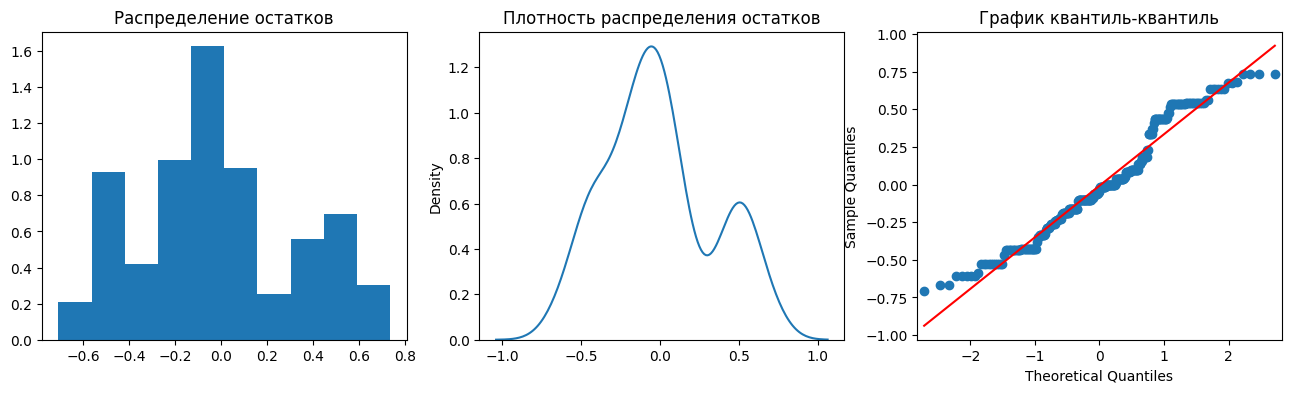

Тест Шапиро-Уилка: 0.9591443985587328, p-value=1.9741402649032608e-07
Тест Колмогорова-Смирнова: 0.2695499497157754, p-value=1.1196828669015615e-19
p-value: 1.9741402649032608e-07
H0 отвергается -- остатки не распределены нормально

7. Мультиколлинеарность
                   Признак       VIF
2  Physical Activity Level  3.224969
3              Daily Steps  2.801463
1         Quality of Sleep  1.340091
4                 Systolic  1.298804
0                   Gender  1.232693
Мультиколлинеарности признаков нет


In [83]:
test_model(model_ridge)

### LASSO-регрессия

In [67]:
model_lasso = sm.OLS(y_train, X_train_with_const)
model_lasso = model_lasso.fit_regularized(L1_wt=1)
print("                     LASSO-регрессия")
pd.DataFrame({"Признак": ["const"] + list(X_train.columns), "Коэффициент": model_lasso.params})

                     LASSO-регрессия


,Признак,Коэффициент
const,const,5.770955
Gender,Gender,-0.123250
Quality of Sleep,Quality of Sleep,2.750308
Physical Activity Level,Physical Activity Level,0.747900
Daily Steps,Daily Steps,-1.043865
Systolic,Systolic,-0.375778


Уравнение идентично предыдущим моделям.

$$ Продолжительность\_сна = -0.123 \cdot Пол + 2.75 \cdot Качество\_сна + 0.747 \cdot Уровень\_активности \\
-1.04 \cdot Количество\_шагов - 0.375 \cdot Верхнее\_давление + 5.77 $$

Более сильные значения получили свободный коэффициент, количество шагов и верхнее давление


1. Линейная связь
H0:Линейная связь отсутствует
H1:Наличие линейной связи
H0 отвергается -- линейная связь есть

2. Случайность остатков
H0:Остатки зависимы
H1:Остатки случайны


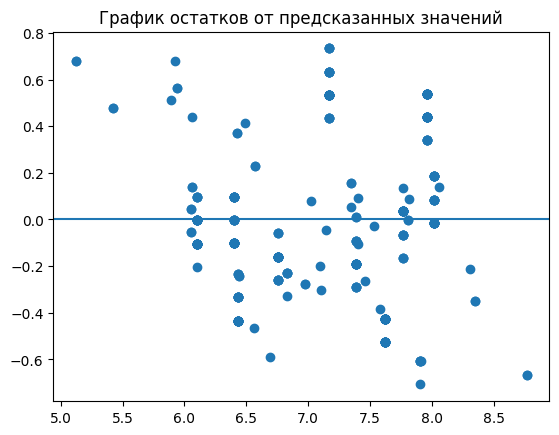


3. Мат ожидание
H0:M(ei) = 0
H1:M(ei) != 0
t расч. = -6.482991415055353
t табл. = 1.9680934526838219
H0 отвергается -- мат. ожидание остатков не равно нулю.

4. Дисперсия
H0:D(ei) = const (гомоскедастичность)
H1: наличие гетероскедастичности
Тест Бройша-Погана
p-value=2.604994474277955e-25
{'Lagrange multiplier statistic': np.float64(125.10071030737525), 'p-value': np.float64(2.604994474277955e-25), 'f-value': np.float64(42.15601821588752), 'f p-value': np.float64(1.2216891290869088e-32)}
H0 отвергается -- дисперсия гетероскедастична

5. Автокоррелияция остатков
H0:Автокорреляция отсутствует
H1:Наличие автокорреляции
Тест Дарбина-Уотсона: 2.058828742692355
H0 подтверждается -- остатки независимы

6. Нормальность остатков
H0:Распределение остатков согласуется с нормальным
H1:распределеие остатков не согласуется с нормальным


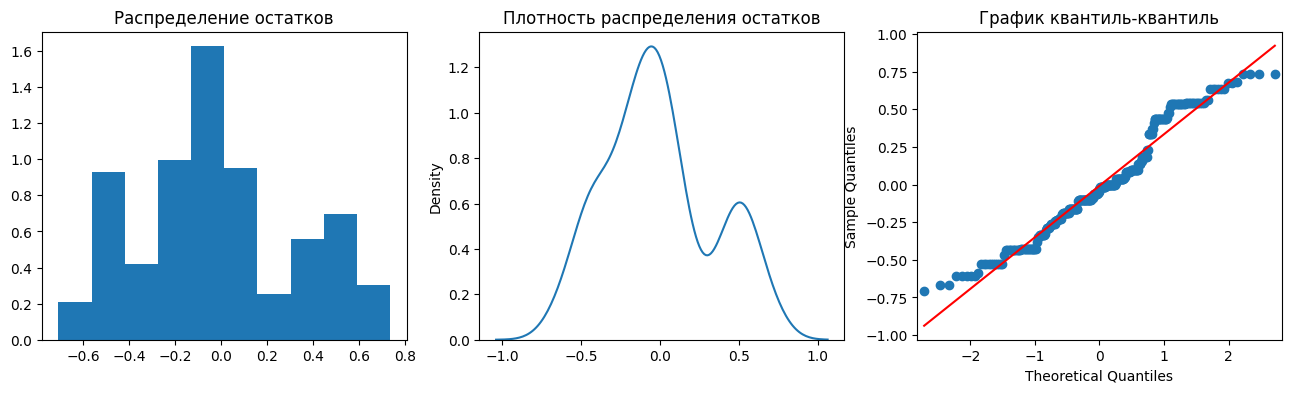

Тест Шапиро-Уилка: 0.9591443985587328, p-value=1.9741402649032608e-07
Тест Колмогорова-Смирнова: 0.2695499497157754, p-value=1.1196828669015615e-19
p-value: 1.9741402649032608e-07
H0 отвергается -- остатки не распределены нормально

7. Мультиколлинеарность
                   Признак       VIF
2  Physical Activity Level  3.224969
3              Daily Steps  2.801463
1         Quality of Sleep  1.340091
4                 Systolic  1.298804
0                   Gender  1.232693
Мультиколлинеарности признаков нет


In [84]:
test_model(model_lasso)

Сравнение моделей линейной регрессии по MAPE, RMSE, MAE

In [69]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, root_mean_squared_error

def evaluate_model(model, name):
    
    prediction = model.predict(sm.add_constant(X_test))
    print(f"""
        {name}
        MAPE: {mean_absolute_percentage_error(y_test, prediction)}
        RMSE: {root_mean_squared_error(y_test, prediction)}
        MAE: {mean_absolute_error(y_test, prediction)}""")

for mod, name in zip([model4_fitted, model_ridge, model_lasso],
                     ["Обычный МНК", "Ridge", "Lasso"]):
    evaluate_model(mod, name)



        Обычный МНК
        MAPE: 0.030349621871741127
        RMSE: 0.29320175798989984
        MAE: 0.21653494997604886

        Ridge
        MAPE: 0.03017755290644222
        RMSE: 0.2923757500062855
        MAE: 0.21630975482598147

        Lasso
        MAPE: 0.03017755290644222
        RMSE: 0.2923757500062855
        MAE: 0.21630975482598147


Все модели показали схожие результаты на тестовой выборке. Ошибка предсказаний составляет от 12 до 17 минут

### Вывод:
Качество подгонки уравнения хорошее, линейная связь между признаками и целевой переменной присутствует, большинстов коэффициентов регрессии значимо. В остатках присутствует автокорреляция, остатки имеют случайный характер и распределены не нормально. Их дисперсия гетероскедастичная, мат. ожидание равно нулю.